# Astronomical survey: calibration, detection, and a reprocessing campaign

The first two notebooks were a fan-in and a chain. This one is the third
shape, and the one most pipelines eventually become: a **campaign**. The
survey is reduced, a catalogue is produced, and then somebody finds a fault
in the calibration and the whole thing is reprocessed. Now two catalogues
exist, both defensible, and the question is which sources changed and why.

Reprocessing is where filename conventions finally give out. `catalogue_v2`,
`catalogue_v2_final`, `catalogue_v2_final_USE_THIS`. What you actually need is
for each catalogue to know which flat field produced it.

```
raw_frame (bias x10) --> master_bias --\
raw_frame (flat x10) --> master_flat ---+--> reduce --> detect --> catalogue
raw_frame (science x6) ----------------/
```

This notebook covers generations, joins across three step types, node
deduplication, comparing two processing runs, and the store as a context
manager.

## 1. Setup

In [1]:
import shutil
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage

import ancestree

WORKDIR = Path(tempfile.mkdtemp(prefix="ancestree-survey-"))
STORE_ROOT = WORKDIR / "survey_2026A"
rng = np.random.default_rng(1618)

SIZE = 256
N_CALIBRATION = 10
N_SCIENCE = 6

## 2. The detector

A synthetic CCD with the defects a real one has: a bias offset, a
vignetted illumination pattern, a scatter of hot pixels, and read noise. The
science frames add stars and a little tracking jitter.

In [2]:
yy, xx = np.mgrid[0:SIZE, 0:SIZE]
radius = np.hypot(yy - SIZE / 2, xx - SIZE / 2) / (SIZE / 2)

TRUE_BIAS = 480.0 + 12.0 * (xx / SIZE)
TRUE_FLAT = np.clip(1.0 - 0.55 * radius**2, 0.30, 1.0)  # strong vignetting
HOT_PIXELS = (rng.random((SIZE, SIZE)) > 0.9994).astype(float) * 3500.0

N_STARS = 55
star_x = rng.uniform(12, SIZE - 12, N_STARS)
star_y = rng.uniform(12, SIZE - 12, N_STARS)
star_flux = 10 ** rng.uniform(2.6, 4.1, N_STARS)


def bias_frame():
    return TRUE_BIAS + rng.normal(0, 4.0, (SIZE, SIZE)) + HOT_PIXELS


def flat_frame():
    # A modest dome-flat level, so the bias pedestal is a sizeable
    # fraction of the signal. That is what makes skipping the debias a
    # real error rather than a rounding one.
    return TRUE_BIAS + TRUE_FLAT * 2_500 + rng.normal(0, 18, (SIZE, SIZE)) + HOT_PIXELS


def science_frame(jitter):
    sky = np.zeros((SIZE, SIZE))
    for x, y, flux in zip(star_x, star_y, star_flux):
        dx, dy = xx - (x + jitter[0]), yy - (y + jitter[1])
        sky += flux * np.exp(-(dx**2 + dy**2) / (2 * 1.8**2))
    sky += 260.0  # sky background
    observed = TRUE_BIAS + TRUE_FLAT * sky + HOT_PIXELS
    return observed + rng.normal(0, 6.0, (SIZE, SIZE))

## 3. Rules, and what makes a generation

The interesting entry is `master_flat`, which may follow either raw frames or
*another master flat*. That is what makes an iterated calibration legal, and
it is what lets a reprocessing campaign be a real descendant of the one it
replaces rather than an unrelated node with a similar name.

`gen_triggers` names it too. A node normally sits at the depth of its deepest
parent; a trigger step goes one past. So every new flat opens a generation,
and everything reduced against it inherits that number.

In [3]:
RULES = {
    "raw_frame": [None],
    "master_bias": ["raw_frame"],
    "master_flat": ["raw_frame", "master_flat"],
    "reduce": ["raw_frame", "master_bias", "master_flat"],
    "detect": ["reduce"],
    "catalogue": ["detect"],
}

store = ancestree.LineageStore(STORE_ROOT, rules=RULES, gen_triggers=["master_flat"])
print(f"gen_triggers: {store.gen_triggers}")
print(f"dedup: {store.reuse_identical}   chunk: {store.delta}")

gen_triggers: ['master_flat']
dedup: True   chunk: True


Rules and policy are written into the database at creation and are immutable
afterwards. Reopening by path is enough to get them back, and passing
different values to an existing store warns and keeps the stored
configuration. To change them, start a new store.

## 4. Ingesting the night's frames

Ten bias frames, ten flats, six science exposures. All roots: they came off
the telescope and have no ancestry in this store.

In [4]:
def ingest(kind, image, **meta):
    with store.create_node(step_type="raw_frame") as node:
        np.save(node / "image.npy", image.astype(np.float32))
        node.add_meta("frame_type", kind, group="Observation")
        node.add_meta("detector", "SYNTH-2k", group="Observation")
        node.add_meta("filter", "r", group="Observation")
        for key, value in meta.items():
            node.add_meta(key, value, group="Observation")
    return node.node_id


bias_ids = [
    ingest("bias", bias_frame(), exposure_s=0.0, sequence=i)
    for i in range(N_CALIBRATION)
]
flat_ids = [
    ingest("flat", flat_frame(), exposure_s=4.0, sequence=i)
    for i in range(N_CALIBRATION)
]

science_ids, jitters = [], []
for i in range(N_SCIENCE):
    jitter = rng.normal(0, 0.6, 2)
    jitters.append(jitter)
    science_ids.append(
        ingest(
            "science",
            science_frame(jitter),
            exposure_s=120.0,
            sequence=i,
            airmass=round(float(1.05 + 0.04 * i), 3),
        )
    )

print(f"{len(store.find(step_type='raw_frame'))} raw frames ingested")
print(f"  bias {len(bias_ids)}   flat {len(flat_ids)}   science {len(science_ids)}")

26 raw frames ingested
  bias 10   flat 10   science 6


Twenty-six frames of the same detector, most of them dominated by the same
fixed pattern. The chunk pool notices.

In [5]:
stats = store.stats()
print(
    f"  logical {stats['logical_bytes'] / 1e6:6.2f} MB   "
    f"stored {stats['chunk_stored_bytes'] / 1e6:6.2f} MB   "
    f"ratio {stats['dedup_ratio']}x"
)

  logical   6.82 MB   stored   5.62 MB   ratio 1.214x


## 5. Master calibration frames

Each master is a join: one node with ten parents. `parent=` takes a list, and
the rules require every one of them to be a legal predecessor.

In [6]:
def stack(node_ids):
    """Median-combine the frames held by a list of nodes."""
    frames = [np.load(store.get(nid) / "image.npy") for nid in node_ids]
    return np.median(np.stack(frames), axis=0), len(frames)


with store.create_node(step_type="master_bias", parent=bias_ids) as node:
    master_bias, n = stack(bias_ids)
    np.save(node / "master_bias.npy", master_bias.astype(np.float32))
    node.add_meta("combine", "median", group="Calibration")
    node.add_meta("frames_combined", n, group="Calibration")
    node.add_meta(
        "mean_level", round(float(master_bias.mean()), 2), group="Calibration"
    )
    node.add_meta(
        "read_noise_adu", round(float(master_bias.std()), 2), group="Calibration"
    )
bias_master_id = node.node_id

with store.create_node(step_type="master_flat", parent=flat_ids) as node:
    stacked, n = stack(flat_ids)
    # v1: the fault. Debiasing is skipped, so the bias pedestal is baked into
    # the flat and every reduced frame inherits a gradient.
    flat_v1 = stacked / np.median(stacked)
    np.save(node / "master_flat.npy", flat_v1.astype(np.float32))
    node.add_meta("version", 1, group="Calibration")
    node.add_meta("combine", "median", group="Calibration")
    node.add_meta("frames_combined", n, group="Calibration")
    node.add_meta("bias_subtracted", False, group="Calibration")
    node.add_meta(
        "dynamic_range",
        round(float(flat_v1.max() / flat_v1.min()), 3),
        group="Calibration",
    )
flat_v1_id = node.node_id

for nid in (bias_master_id, flat_v1_id):
    record = store.get(nid)
    print(
        f"{record.step_type:<12} {nid}  generation {record.generation}  "
        f"parents {len(record.parent_id)}"
    )

master_bias  682c68a4  generation 0  parents 10
master_flat  ab4ec8e4  generation 1  parents 10


The bias master sits at generation 0 alongside its parents. The flat is a
generation trigger, so it opens generation 1 and everything reduced against
it will follow.

## 6. Node deduplication

Before reducing anything, a demonstration of something easy to trip over.
Rerun the bias stack with identical inputs and identical metadata:

In [7]:
before = store.stats()["nodes"]

with store.create_node(step_type="master_bias", parent=bias_ids) as node:
    repeat, n = stack(bias_ids)
    np.save(node / "master_bias.npy", repeat.astype(np.float32))
    node.add_meta("combine", "median", group="Calibration")
    node.add_meta("frames_combined", n, group="Calibration")
    node.add_meta("mean_level", round(float(repeat.mean()), 2), group="Calibration")
    node.add_meta("read_noise_adu", round(float(repeat.std()), 2), group="Calibration")

print(f"nodes before {before}, after {store.stats()['nodes']}")
print(f"the handle rebound onto the existing node: {node.node_id == bias_master_id}")

nodes before 28, after 28
the handle rebound onto the existing node: True


Nothing was stored. Identical content (step type, parents, metadata and
artifact bytes) collapses onto the node that already exists, and the block's
variable is rebound onto it. This is why `node.node_id` must be read *after*
the block: an id copied out mid-block can name a node that was never
persisted, and passing it as a parent later raises.

Change any input and you get a distinct node. Failed runs never merge. If you
want a record of every run regardless, create the store with `reuse_identical=False`.

### And a node that wrote nothing

A block that neither writes an artifact nor adds metadata is discarded rather
than committed, because an empty node is almost always a bug.

In [8]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    with store.create_node(step_type="raw_frame") as empty:
        pass  # a step that did nothing
    print(f"UserWarning: {caught[0].message}")

print(f"\nstore still holds {store.stats()['nodes']} nodes")


store still holds 28 nodes


## 7. Reduction and detection

Each science frame is reduced against both masters: a three-parent join of
the raw frame, the bias and the flat. That edge is the whole point. Six
months later, "which flat produced this?" is a graph query, not an
archaeology exercise.

In [9]:
def reduce_and_detect(science_id, bias_id, flat_id, label):
    """Debias, flat-field, detect sources. Returns (reduce_id, detect_id)."""
    with store.create_node(
        step_type="reduce", parent=[science_id, bias_id, flat_id]
    ) as node:
        raw = np.load(store.get(science_id) / "image.npy")
        bias = np.load(store.get(bias_id) / "master_bias.npy")
        flat = np.load(store.get(flat_id) / "master_flat.npy")

        reduced = (raw - bias) / flat
        np.save(node / "reduced.npy", reduced.astype(np.float32))

        node.add_meta("calibration_run", label, group="Reduction")
        node.add_meta(
            "flat_version",
            store.get(flat_id).metadata["version"]["value"],
            group="Reduction",
        )
        node.add_meta(
            "sky_level", round(float(np.median(reduced)), 2), group="Reduction"
        )
        node.add_meta("sky_rms", round(float(reduced.std()), 2), group="Reduction")
    reduce_id = node.node_id

    with store.create_node(step_type="detect", parent=reduce_id) as node:
        image = np.load(store.get(reduce_id) / "reduced.npy")
        background = np.median(image)
        noise = 1.4826 * np.median(np.abs(image - background))
        mask = image > background + 5 * noise

        labels, _ = ndimage.label(mask)
        found = ndimage.find_objects(labels)
        sources = []
        for index, window in enumerate(found, start=1):
            pixels = labels[window] == index
            if pixels.sum() < 4:
                continue
            cutout = image[window] - background
            total = float((cutout * pixels).sum())
            cy, cx = ndimage.center_of_mass(cutout * pixels)
            sources.append(
                {
                    "x": round(float(window[1].start + cx), 2),
                    "y": round(float(window[0].start + cy), 2),
                    "flux": round(total, 1),
                    "pixels": int(pixels.sum()),
                }
            )
        table = pd.DataFrame(sources).sort_values("flux", ascending=False)
        table.to_csv(node / "sources.csv", index=False)

        node.add_meta("calibration_run", label, group="Detection")
        node.add_meta("sources_found", len(table), group="Detection")
        node.add_meta(
            "detection_threshold", round(float(5 * noise), 2), group="Detection"
        )
        node.add_meta(
            "faintest_flux", round(float(table["flux"].min()), 1), group="Detection"
        )
    return reduce_id, node.node_id


run_v1 = [
    reduce_and_detect(sid, bias_master_id, flat_v1_id, "v1") for sid in science_ids
]
detect_v1 = [d for _, d in run_v1]

print(f"run v1: {len(detect_v1)} frames reduced and searched")
print(
    f"sources per frame: "
    f"{[store.get(d).metadata['sources_found']['value'] for d in detect_v1]}"
)

run v1: 6 frames reduced and searched
sources per frame: [46, 46, 46, 46, 46, 46]


## 8. The catalogue

One node joining every detection, holding the merged source list and a
preview image. A `Path` passed to `add_meta` is recognised as an image by its
suffix and rendered inline in the explorer.

In [10]:
def build_catalogue(detect_ids, label):
    with store.create_node(step_type="catalogue", parent=detect_ids) as node:
        tables = []
        for frame, detect_id in enumerate(detect_ids):
            table = pd.read_csv(store.get(detect_id) / "sources.csv")
            table["frame"] = frame
            tables.append(table)
        merged = pd.concat(tables, ignore_index=True)

        # Cross-match by position across frames: brightest first, each
        # detection either joining an existing source within the match radius
        # or opening a new one.
        entries = []
        for row in merged.sort_values("flux", ascending=False).itertuples():
            for entry in entries:
                if np.hypot(entry["x"] - row.x, entry["y"] - row.y) <= 3.0:
                    entry["fluxes"].append(row.flux)
                    break
            else:
                entries.append({"x": row.x, "y": row.y, "fluxes": [row.flux]})

        catalogue = pd.DataFrame(
            [
                {
                    "x": round(e["x"], 2),
                    "y": round(e["y"], 2),
                    "flux": round(float(np.mean(e["fluxes"])), 1),
                    "detections": len(e["fluxes"]),
                }
                for e in entries
            ]
        ).sort_values("flux", ascending=False)
        catalogue.to_csv(node / "catalogue.csv", index=False)
        merged.to_csv(node / "detections_all_frames.csv", index=False)

        node.add_meta("calibration_run", label, group="Catalogue")
        node.add_meta("sources", len(catalogue), group="Catalogue")
        node.add_meta("frames", len(detect_ids), group="Catalogue")
        node.add_meta(
            "mean_detections_per_source",
            round(float(catalogue["detections"].mean()), 2),
            group="Catalogue",
        )
        node.add_meta(
            "brightest", catalogue.head(5), group="Catalogue", data_type="table"
        )
    return node.node_id, catalogue


catalogue_v1_id, catalogue_v1 = build_catalogue(detect_v1, "v1")
record = store.get(catalogue_v1_id)
print(
    f"catalogue {catalogue_v1_id}  generation {record.generation}  "
    f"{record.metadata['sources']['value']} sources from "
    f"{record.metadata['frames']['value']} frames"
)

catalogue 0b8c8402  generation 1  46 sources from 6 frames


## 9. The fault

The flat was never debiased, so it carries the detector's bias pedestal. That
pedestal is nearly constant across the field while the illumination falls off
towards the corners, so the flat is *flatter* than the detector's true
response. Dividing by it therefore over-corrects: the corners of every reduced
frame come out too dim.

In [11]:
def sky_flatness(image):
    """Median sky at the centre against the four corners. Medians, not means,
    because stars would otherwise dominate. A correctly flat-fielded frame has
    the same sky everywhere."""
    centre = float(np.median(image[112:144, 112:144]))
    corners = float(
        np.median(
            np.concatenate(
                [
                    image[:40, :40].ravel(),
                    image[:40, -40:].ravel(),
                    image[-40:, :40].ravel(),
                    image[-40:, -40:].ravel(),
                ]
            )
        )
    )
    return centre, corners, (corners - centre) / centre


reduced_v1 = np.load(store.get(run_v1[0][0]) / "reduced.npy")
centre, corners, residual = sky_flatness(reduced_v1)
print("reduced frame, run v1:")
print(f"  sky at the centre    {centre:8.2f}")
print(f"  sky in the corners   {corners:8.2f}")
print(f"  residual vignetting  {residual:8.1%}   (should be near zero)")

reduced frame, run v1:
  sky at the centre      183.69
  sky in the corners     136.32
  residual vignetting    -25.8%   (should be near zero)


## 10. The reprocessing campaign

A corrected flat: debias first, then normalise. Its parents are the raw flats
*and the flat it replaces*, which the rules permit. That makes the new
calibration a descendant of the old one rather than an orphan, and because
`master_flat` is a generation trigger, it opens generation 2.

In [12]:
with store.create_node(step_type="master_flat", parent=[*flat_ids, flat_v1_id]) as node:
    stacked, n = stack(flat_ids)
    debiased = stacked - master_bias
    flat_v2 = debiased / np.median(debiased)
    np.save(node / "master_flat.npy", flat_v2.astype(np.float32))

    node.add_meta("version", 2, group="Calibration")
    node.add_meta("combine", "median", group="Calibration")
    node.add_meta("frames_combined", n, group="Calibration")
    node.add_meta("bias_subtracted", True, group="Calibration")
    node.add_meta(
        "dynamic_range",
        round(float(flat_v2.max() / flat_v2.min()), 3),
        group="Calibration",
    )
    node.add_meta("supersedes", flat_v1_id, group="Calibration")
    node.add_meta(
        "reason",
        "v1 was not debiased; reduced frames carry a left-to-right gradient",
        group="Calibration",
        searchable=False,
    )
flat_v2_id = node.node_id

v2 = store.get(flat_v2_id)
print(f"master_flat v2 {flat_v2_id}")
print(f"  generation {v2.generation} (v1 was {store.get(flat_v1_id).generation})")
print(
    f"  parents    {len(v2.parent_id)} "
    f"({len(flat_ids)} raw flats plus the flat it supersedes)"
)

master_flat v2 61efef63
  generation 2 (v1 was 1)
  parents    11 (10 raw flats plus the flat it supersedes)


In [13]:
run_v2 = [
    reduce_and_detect(sid, bias_master_id, flat_v2_id, "v2") for sid in science_ids
]
detect_v2 = [d for _, d in run_v2]
catalogue_v2_id, catalogue_v2 = build_catalogue(detect_v2, "v2")

reduced_v2 = np.load(store.get(run_v2[0][0]) / "reduced.npy")
centre2, corners2, residual2 = sky_flatness(reduced_v2)
print("reduced frame, run v2:")
print(f"  residual vignetting  {residual2:8.1%}   (was {residual:.1%})")
print(f"\ncatalogue v2: {len(catalogue_v2)} sources (v1 found {len(catalogue_v1)})")

reduced frame, run v2:
  residual vignetting      1.0%   (was -25.8%)

catalogue v2: 43 sources (v1 found 46)


## 11. Comparing the two campaigns

Both catalogues are in the store, both complete, both traceable. Generation
separates them.

In [14]:
rows = store.sql(
    """
    SELECT generation,
           step_type,
           count(*) AS nodes
    FROM node
    GROUP BY generation, step_type
    ORDER BY generation, min(created_epoch)
    """
)
print(pd.DataFrame([dict(r) for r in rows]).to_string(index=False))

 generation   step_type  nodes
          0   raw_frame     26
          0 master_bias      1
          1 master_flat      1
          1      reduce      6
          1      detect      6
          1   catalogue      1
          2 master_flat      1
          2      reduce      6
          2      detect      6
          2   catalogue      1


The question that matters is which flat a given catalogue was built on.
`ancestors` is `find` restricted to a node's lineage, so it answers in one
call regardless of how deep the pipeline is.

In [15]:
for label, catalogue_id in [("v1", catalogue_v1_id), ("v2", catalogue_v2_id)]:
    flat = store.ancestors(catalogue_id, step_type="master_flat")[-1]
    record = store.get(catalogue_id)
    print(f"catalogue {label}  ({catalogue_id}, generation {record.generation})")
    print(
        f"  built on master_flat {flat.node_id}  "
        f"version {flat.metadata['version']['value']}  "
        f"bias_subtracted {flat.metadata['bias_subtracted']['value']}"
    )
    print(
        f"  sources {record.metadata['sources']['value']}, "
        f"lineage depth {len(store.lineage(catalogue_id))} nodes"
    )

catalogue v1  (0b8c8402, generation 1)
  built on master_flat ab4ec8e4  version 1  bias_subtracted False
  sources 46, lineage depth 41 nodes
catalogue v2  (dbd21499, generation 2)
  built on master_flat 61efef63  version 2  bias_subtracted True
  sources 43, lineage depth 42 nodes


Note `ancestors(catalogue_v2_id, step_type="master_flat")` returns **two**
flats, because v2 genuinely descends from v1. Taking `[-1]` gets the one it
was actually reduced against; the presence of the other is the audit trail.

In [16]:
chain = store.ancestors(catalogue_v2_id, step_type="master_flat")
for flat in chain:
    print(
        f"  gen {flat.generation}  {flat.node_id}  "
        f"v{flat.metadata['version']['value']}  "
        f"debiased={flat.metadata['bias_subtracted']['value']}"
    )

  gen 1  ab4ec8e4  v1  debiased=False
  gen 2  61efef63  v2  debiased=True


### What changed scientifically

Detection counts per frame, from metadata rather than from files.

In [17]:
comparison = pd.DataFrame(
    {
        "frame": range(N_SCIENCE),
        "v1_sources": [
            store.get(d).metadata["sources_found"]["value"] for d in detect_v1
        ],
        "v2_sources": [
            store.get(d).metadata["sources_found"]["value"] for d in detect_v2
        ],
        "v1_sky_rms": [store.get(r).metadata["sky_rms"]["value"] for r, _ in run_v1],
        "v2_sky_rms": [store.get(r).metadata["sky_rms"]["value"] for r, _ in run_v2],
    }
)
comparison["change"] = comparison["v2_sources"] - comparison["v1_sources"]
print(comparison.to_string(index=False))
print(f"\nnet change: {comparison['change'].sum():+d} detections across the survey")

 frame  v1_sources  v2_sources  v1_sky_rms  v2_sky_rms  change
     0          46          43      293.01      296.37      -3
     1          46          43      292.96      296.30      -3
     2          46          43      292.97      296.28      -3
     3          46          43      292.95      296.36      -3
     4          46          43      292.99      296.36      -3
     5          46          43      292.97      296.40      -3

net change: -18 detections across the survey


The corrected run finds *fewer* sources, which is not the result the
reprocessing was expected to produce. It is worth stopping on, because this is
exactly the situation the store exists for: two catalogues disagree, and the
question is which to believe.

The star positions and fluxes are known here, so both runs can be scored
rather than argued about.

In [18]:
def score(catalogue, tolerance=3.0):
    """Match a catalogue against the stars that were actually placed, and
    measure both completeness and photometric accuracy."""
    matched, spurious = [], 0
    for row in catalogue.itertuples():
        distances = np.hypot(star_x - row.x, star_y - row.y)
        index = int(distances.argmin())
        if distances[index] <= tolerance:
            star_radius = np.hypot(
                star_y[index] - SIZE / 2, star_x[index] - SIZE / 2
            ) / (SIZE / 2)
            matched.append((row.flux / star_flux[index], star_radius))
        else:
            spurious += 1

    ratios = np.array([m[0] for m in matched])
    radii = np.array([m[1] for m in matched])
    # Only the *shape* of the response matters: an overall scale factor is
    # absorbed by the zero point, a position-dependent one is not.
    normalised = ratios / np.median(ratios)
    inner, outer = normalised[radii < 0.4], normalised[radii > 0.7]
    return {
        "catalogue": len(catalogue),
        "real": len(matched),
        "spurious": spurious,
        "recall": round(len(matched) / N_STARS, 3),
        "phot_scatter": round(float(np.median(np.abs(normalised - 1))), 4),
        "inner_flux": round(float(inner.mean()), 3),
        "outer_flux": round(float(outer.mean()), 3),
        "radial_bias": round(float(outer.mean() / inner.mean() - 1), 3),
    }


quality = pd.DataFrame(
    [
        {"run": label, **score(cat)}
        for label, cat in [("v1", catalogue_v1), ("v2", catalogue_v2)]
    ]
)
print(f"{N_STARS} stars were actually placed in the field\n")
print(quality.to_string(index=False))

55 stars were actually placed in the field

run  catalogue  real  spurious  recall  phot_scatter  inner_flux  outer_flux  radial_bias
 v1         46    45         1   0.818        0.0971       1.198       0.948       -0.208
 v2         43    41         2   0.745        0.0326       1.095       1.102        0.007


That settles it, and not in the direction the counts suggested.

Run v1 recovers slightly *more* real stars, because over-correcting the
vignetting depresses the corners, which drags down the global background the
detection threshold is built from. A lower threshold finds more faint things.

But look at `radial_bias`. In run v1 a star in the corners is measured about
21% fainter than the same star at the centre, so every colour, every light
curve and every calibration built on that catalogue carries a position
dependent error. Run v2 is flat to under 1%, with a third of the scatter.

The reprocessing traded three marginal detections for photometry that can
actually be used, and both catalogues remain in the store with the flat that
produced each one attached. Nobody has to take this write-up on trust.

In [19]:
comparison_summary = {
    "v1_radial_bias": float(quality.loc[0, "radial_bias"]),
    "v2_radial_bias": float(quality.loc[1, "radial_bias"]),
    "v1_recall": float(quality.loc[0, "recall"]),
    "v2_recall": float(quality.loc[1, "recall"]),
}
comparison_summary

{'v1_radial_bias': -0.208,
 'v2_radial_bias': 0.007,
 'v1_recall': 0.818,
 'v2_recall': 0.745}

## 12. A final node with the evidence

The comparison itself deserves to be a node. It joins nothing new, it just
records the conclusion where the lineage can find it.

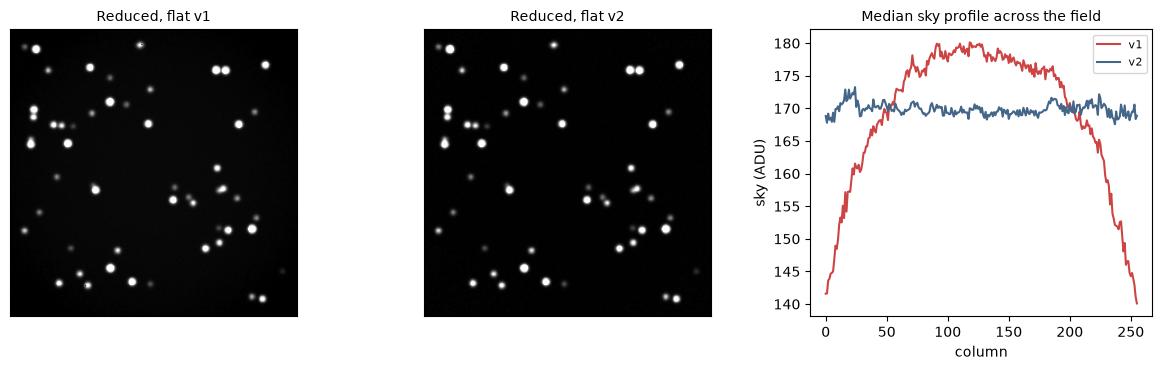

summary node e7bb0aaf


In [20]:
with store.create_node(step_type="catalogue", parent=detect_v2) as node:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, image, title in [
        (axes[0], reduced_v1, "Reduced, flat v1"),
        (axes[1], reduced_v2, "Reduced, flat v2"),
    ]:
        vmin, vmax = np.percentile(image, [5, 99.2])
        ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for image, label, colour in [
        (reduced_v1, "v1", "#c44"),
        (reduced_v2, "v2", "#468"),
    ]:
        profile = np.median(image, axis=0)
        axes[2].plot(profile, label=label, color=colour)
    axes[2].set_title("Median sky profile across the field", fontsize=10)
    axes[2].set_xlabel("column")
    axes[2].set_ylabel("sky (ADU)")
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(node / "flat_comparison.png", dpi=110)
    plt.show()

    comparison.to_csv(node / "run_comparison.csv", index=False)

    node.add_meta("calibration_run", "v2-summary", group="Comparison")
    node.add_meta("v1_catalogue", catalogue_v1_id, group="Comparison")
    node.add_meta("v2_catalogue", catalogue_v2_id, group="Comparison")
    node.add_meta(
        "net_detection_change", int(comparison["change"].sum()), group="Comparison"
    )
    node.add_meta(
        "v1_radial_bias", comparison_summary["v1_radial_bias"], group="Comparison"
    )
    node.add_meta(
        "v2_radial_bias", comparison_summary["v2_radial_bias"], group="Comparison"
    )
    node.add_meta(
        "verdict",
        "v2 supersedes v1: v1 photometry carries a 21% radial bias",
        group="Comparison",
    )
    node.add_meta("scoring", quality, group="Comparison", data_type="table")
    node.add_meta("per_frame", comparison, group="Comparison", data_type="table")
    node.add_meta(
        "evidence", node / "flat_comparison.png", group="Comparison", data_type="image"
    )
    node.add_meta(
        "proposal",
        "https://example.org/proposals/2026A-014",
        group="Comparison",
        data_type="link",
    )

summary_id = node.node_id
print(f"summary node {summary_id}")

## 13. Finding files

`artifacts(contains=...)` matches both as a glob and as a case-insensitive
substring anywhere in the filename, so you can reach for whichever is more
natural.

In [21]:
summary = store.get(summary_id)
print(f"all:        {[p.name for p in summary.artifacts()]}")
print(f"glob:       {[p.name for p in summary.artifacts('*.png')]}")
print(f"substring:  {[p.name for p in summary.artifacts('comparison')]}")

all:        ['flat_comparison.png', 'run_comparison.csv']
glob:       ['flat_comparison.png']
substring:  ['flat_comparison.png', 'run_comparison.csv']


## 14. Reopening the store

`LineageStore` is a context manager, and reopening by path is enough: rules,
generation triggers and policy all come back out of the database. Nothing
about the pipeline lives in the calling code.

In [22]:
store.close()

with ancestree.LineageStore(STORE_ROOT) as reopened:
    print(f"rules recovered:      {list(reopened.rules)}")
    print(f"gen_triggers:         {reopened.gen_triggers}")
    print(f"reuse_identical / chunk:  {reopened.reuse_identical} / {reopened.delta}")
    print(f"nodes:                {reopened.stats()['nodes']}")

    newest = reopened.latest(step_type="catalogue")
    print(f"\nlatest catalogue:     {newest.node_id} (generation {newest.generation})")
    print(
        f"its flat:             v"
        f"{reopened.ancestors(newest, step_type='master_flat')[-1].metadata['version']['value']}"
    )

rules recovered:      ['raw_frame', 'master_bias', 'master_flat', 'reduce', 'detect', 'catalogue']
gen_triggers:         ['master_flat']
reuse_identical / chunk:  True / True
nodes:                56

latest catalogue:     e7bb0aaf (generation 2)
its flat:             v2


## 15. Handing it over

In [23]:
store = ancestree.LineageStore(STORE_ROOT)

graph = store.generate_web_graph()
print(f"web graph  {graph.name}  ({graph.stat().st_size / 1024:.0f} KiB)")

exported = store.export(WORKDIR / "survey_export")
print(f"sidecars   {len(list(exported.rglob('meta.json')))} meta.json files")

backup = store.backup(WORKDIR / "survey_backup.db")
print(f"backup     {backup.name} ({backup.stat().st_size / 1e6:.1f} MB)")

final = store.stats()
print(f"\n{final['nodes']} nodes, {final['artifacts']} artifacts")
print(
    f"logical {final['logical_bytes'] / 1e6:.1f} MB  ->  "
    f"pool {final['chunk_stored_bytes'] / 1e6:.1f} MB  "
    f"({final['dedup_ratio']}x), database {final['database_bytes'] / 1e6:.1f} MB"
)

web graph  interactive_pipeline.html  (741 KiB)
sidecars   56 meta.json files
backup     survey_backup.db (10.4 MB)

56 nodes, 59 artifacts
logical 10.9 MB  ->  pool 9.1 MB  (1.207x), database 10.4 MB


Two full reductions of the same survey, both kept in their entirety, for
little more than one. Most of the sharing is exact chunk deduplication: the
raw frames are untouched between runs, and the reduced frames differ only by
the calibration applied.

For a store this shape the live explorer is worth more than the static
snapshot, because you want to filter rather than browse:

```python
store.host_live_graph()          # searchable explorer on localhost
```

It takes `field=value`, numeric filters like `sources_found>40`, and free
text. Pin the two catalogue nodes for a side-by-side diff of their metadata,
or sort the runs table by any column.

## What this bought

- Two calibration runs distinguishable by generation, not by filename, and
  scoreable against each other after the fact.
- A surprising result (the corrected run found fewer sources) resolved by
  evidence rather than argument, because both runs were kept in full.
- Each catalogue's flat recoverable in one call, and v2's ancestry showing
  the flat it superseded.
- The reason for the reprocessing stored on the node that caused it.
- A rerun that produced identical output collapsing to nothing.
- The whole survey, twice reduced, in a single file you can copy.

In [24]:
# store.close()
# shutil.rmtree(WORKDIR, ignore_errors=True)
store.host_live_graph()

Ancestree explorer running at: http://127.0.0.1:50846  (Store close will terminate background thread)


'http://127.0.0.1:50846'